In [263]:
%load_ext autoreload
%autoreload 2
import numpy as np
import geopandas as gpd
import pandas as pd
import os
from tile import tile_sampler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [264]:
os.getcwd()
os.chdir(r'c:\\Users\\solan\\OneDrive\\Desktop\\IntrotoPython\\FinalProj\\cropfield-polygonization\\data')

zambia_shp = gpd.read_parquet(r'zambia_2023_attributed.parquet')

In [265]:
# test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)
test_tile = zambia_shp[zambia_shp['tile_id'] == 883180]

# Look at the bottom 25% compactness, top 25% shape index, top 25% interior edge, top 25% fractal dim
test_tile_filt = test_tile[(test_tile["compactness"] <= test_tile["compactness"].quantile(0.25)) & (test_tile["shape_index"] >= test_tile["shape_index"].quantile(0.75)) & (test_tile["interior_edge"] >= test_tile["interior_edge"].quantile(0.75)) & (test_tile["fractal_dim"] >= test_tile["fractal_dim"].quantile(0.75))]

In [293]:
test_tile_filt = test_tile_filt.to_crs(32735)
test_tile_filt.describe()

print(test_tile_filt.crs)

EPSG:32735


In [305]:
from shapely.ops import split
from shapely.geometry import Point
from shapely.ops import nearest_points
from shapely import LineString
import pandas as pd

def poly_splitter(gdf, perimeter_column, geometry_column, delta):
    """
        This function splits a polygon at the narrowest point determined using a negative buffer. 

        Arguments: 
        gdf : Geodataframe
        perimeter_column : Name of column with perimeter values
        delta: buffer step (should be positive)

        Required packages: Shapely, pandas
        
        Other relevant packages: geopandas (geodataframe creation and loading), os (directory navigation)
    """
    gdf = gdf.copy()
    gdf['sdist'] = None
    gdf['buffers_geom'] = None
    gdf['buffer_geom1'] = None
    gdf['buffer_geom2'] = None
    gdf['pinch1'] = None
    gdf['pinch2'] = None
    gdf['line'] = None
    gdf['cut_geom1'] = None
    gdf['cut_geom2'] = None

    for idx, row in gdf.iterrows():
        max_len = gdf.at[idx, perimeter_column]
        current_buff = 0
        while current_buff <= max_len:
            current_buff += delta
            buffered = row[geometry_column].buffer(-current_buff)
            if buffered.geom_type == 'MultiPolygon':
                geoms = list(buffered.geoms)
                print(f"Split at row {idx}, buffer distance {current_buff:.3f}")
                gdf.at[idx, 'buffers_geom'] = buffered
                gdf.at[idx, 'sdist'] = -current_buff  # keep negative to match original
                gdf.at[idx, 'buffer_geom1'] = geoms[0]
                gdf.at[idx, 'buffer_geom2'] = geoms[1]
                break
        else:
            print(f"No split for row {idx} within max_len={max_len}")

    # Connecting narrowest part
    for idx, row in gdf.iterrows():
        if pd.isna(row['sdist']):
            continue
        else:
            p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
            gdf.at[idx, 'pinch1'] = p1
            gdf.at[idx, 'pinch2'] = p2
            gdf.at[idx, 'line'] = LineString([p1, p2])

    # Creating Cut Line (Perpendicular Line) and cutting
    for idx, row in gdf.iterrows():
        if pd.isna(row['sdist']):
            continue
        else: 
            bounds = gdf.at[idx, geometry_column].bounds
            dist = max(bounds[2] - bounds[0], bounds[3] - bounds[1])
            point1 = gdf.at[idx, 'pinch1']
            point2 = gdf.at[idx, 'pinch2']
            dx = point1.x - point2.x
            dy = point1.y - point2.y
            midpoint = Point((point1.x + point2.x) / 2, (point1.y + point2.y) / 2)
            perp_slope = -(dx/dy)
            perp_line = LineString([(midpoint.x - dist, midpoint.y - perp_slope * dist), (midpoint.x + dist, midpoint.y + perp_slope * dist)])
            cut = split(gdf.at[idx, 'geometry'], perp_line)
            gdf.at[idx, 'cut_geom1'] = cut.geoms[0]
            gdf.at[idx, 'cut_geom2'] = cut.geoms[1] 

poly_splitter(test_tile_filt, 'perimeter_m', 'geometry', delta=0.1)


Split at row 8104396, buffer distance 5.200
Split at row 8104405, buffer distance 5.300
Split at row 8104443, buffer distance 4.100
Split at row 8104482, buffer distance 1.900
Split at row 8104492, buffer distance 4.800
Split at row 8104495, buffer distance 4.900
Split at row 8104549, buffer distance 2.000
Split at row 8104770, buffer distance 4.100
No split for row 8104789 within max_len=74.97936365310889
Split at row 8104866, buffer distance 3.100
Split at row 8104900, buffer distance 2.700
Split at row 8104917, buffer distance 0.800
Split at row 8104979, buffer distance 5.300
No split for row 8105034 within max_len=80.6476354270216
No split for row 8105097 within max_len=78.21013916343942
Split at row 8105139, buffer distance 4.400
Split at row 8105197, buffer distance 1.400
No split for row 8105200 within max_len=89.81168353807075
No split for row 8105230 within max_len=94.09380581130623
No split for row 8105357 within max_len=112.24940828466555
Split at row 8105360, buffer distanc

<Axes: >

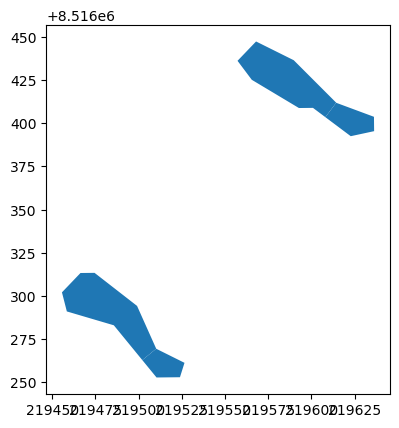

In [304]:
import geopandas as gpd

fig, ax = plt.subplots()
gpd.GeoSeries(test_tile_filt['cut_geom1'].head(2).dropna()).plot(ax = ax)
gpd.GeoSeries(test_tile_filt['cut_geom2'].head(2).dropna()).plot(ax = ax)

In [ ]:
from shapely.geometry import Point

# Test poly (1)
point = Point(24.4135987, -13.3993874)  

# Select the polygon that contains the point
test_poly = test_tile[test_tile.geometry.contains(point)]
test_poly = test_poly.to_crs(32735)

test_poly.info()

test_poly.plot()

In [ ]:
test_poly.geometry.bounds

pd.set_option('display.max_colwidth', None)

geom = test_poly['geometry'].iloc[0]

coords = list(geom.exterior.coords)


x, y = zip(*coords)

minx, maxx = min(x), max(x)
miny, maxy = min(y), max(y)
print(minx, maxx)
print(miny, maxy)
print(test_poly.geometry.bounds)

In [ ]:
# TEST
# zam_filt['min_len'] = zam_filt.geometry.apply(
#     lambda g: -(min(g.bounds[2] - g.bounds[0], g.bounds[3] - g.bounds[1]) / 2)
# )

import matplotlib.pyplot as plt 
import matplotlib.cm as cm 

fig, ax = plt.subplots()

delta = .5 # buffer step
max_len = 1000000

idx = test_poly.index[0]

buffers = []
current_buff = 0

while current_buff <= max_len:
    current_buff += delta
    buffered = test_poly['geometry'].iloc[0].buffer(-current_buff)
    buffers.append(buffered)
    if buffered.geom_type == 'MultiPolygon':
        geoms = list(buffered.geoms)
        print(f"Split happened at buffer distance {current_buff}.")
        test_poly.loc[idx, 'geometry_test'] = buffered # buffer geometry
        test_poly.loc[idx, 'sdist'] = -current_buff #buffer 
        test_poly.loc[idx, 'buffer_geom1'] = geoms[0] # geometry 1 for split poly
        test_poly.loc[idx, 'buffer_geom2'] = geoms[1] # geometry 2 for split poly
        break
else:
    print(f"No split within dimension limit")


for geom, color in zip(buffers, colors): 
    gpd.GeoSeries([geom]).plot(ax = ax, facecolor = 'none', edgecolor = 'blue', linewidth = 0.5)

test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
plt.title(f"Buffer progression — split at {current_buff:.2f}")
plt.show()

In [ ]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
plt.show()

In [ ]:
# NEAREST POINTS TEST

from shapely.ops import nearest_points
from shapely import ops 
from shapely import LineString


p1, p2 = nearest_points(test_poly['buffer_geom1'].iloc[0], test_poly['buffer_geom2'].iloc[0])
test_poly.at[idx, 'pinch1'] = p1
test_poly.at[idx, 'pinch2'] = p2
test_poly.at[idx, 'line'] = LineString([p1, p2]) # line connecting closest points

# Goal is to create perpendicular line? 

fig, ax = plt.subplots()
test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
plt.show()
# line_buff = test_poly['line'].buffer(abs(row['sdist']))
# zam_filt.at[idx, 'line_buff'] = line_buff

In [ ]:
test_poly['geometry'].length

In [ ]:
dist

In [ ]:
# Finding perpendicular line to connecting line
line = gpd.GeoDataFrame(geometry = test_poly['line']) # original polygon line

dist = (test_poly['geometry'].length)*.01

point1 = test_poly['pinch1'].iloc[0]
point2 = test_poly['pinch2'].iloc[0]

dx = point1.x - point2.x
dy = point1.y - point2.y
 
midpoint = Point(
    (point1.x + point2.x) / 2,
    (point1.y + point2.y) / 2
)

perp_slope = -(dx/dy)

perp_line = LineString([(midpoint.x - dist, midpoint.y - perp_slope * dist), (midpoint.x + dist, midpoint.y + perp_slope * dist)])

In [ ]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
gpd.GeoSeries(perp_line).plot(ax=ax, color = 'red')
gpd.GeoSeries([midpoint]).plot(ax=ax, color = 'green', markersize = 10)
plt.show()

In [ ]:
fig, ax = plt.subplots()
test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
gpd.GeoSeries(perp_line).plot(ax=ax, color = 'purple')
plt.show()

In [ ]:
test_poly

In [ ]:
gpd.GeoSeries(perp_line)
from shapely.ops import split

cut = split(test_poly['geometry'].iloc[0], perp_line)

test_poly['cut_geom1'] = cut.geoms[0]
test_poly['cut_geom2'] = cut.geoms[1]

fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['cut_geom1']).plot(ax = ax)
gpd.GeoSeries(test_poly['cut_geom2']).plot(ax = ax)

Now trying with test_tile

In [276]:
# test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)

test_tile = zambia_shp[zambia_shp['tile_id'] == 883180]
test_tile = test_tile.to_crs(32735)
display(test_tile['geometry'].length)
test_tile.info()

8104387     148.587853
8104388     189.251256
8104389      70.792060
8104390     495.797101
8104391     291.376526
              ...     
8106361    1109.494730
8106362    1028.369596
8106363     363.904232
8106364     119.845620
8106365     194.675938
Length: 1979, dtype: float64

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1979 entries, 8104387 to 8106365
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        1979 non-null   float64 
 1   area_ha        1979 non-null   float64 
 2   perimeter_m    1979 non-null   float64 
 3   compactness    1979 non-null   float64 
 4   shape_index    1979 non-null   float64 
 5   interior_edge  1979 non-null   float64 
 6   fractal_dim    1979 non-null   float64 
 7   tile_id        1979 non-null   float64 
 8   polygon_index  1979 non-null   float64 
 9   polygon_id     1979 non-null   float64 
 10  geometry       1979 non-null   geometry
dtypes: float64(10), geometry(1)
memory usage: 185.5 KB


In [277]:
tile_filt = test_tile[(test_tile["compactness"] <= test_tile["compactness"].quantile(0.25)) & (test_tile["shape_index"] >= test_tile["shape_index"].quantile(0.75)) & (test_tile["interior_edge"] >= test_tile["interior_edge"].quantile(0.75)) & (test_tile["fractal_dim"] >= test_tile["fractal_dim"].quantile(0.75))]
tile_filt.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 41 entries, 8104396 to 8106014
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        41 non-null     float64 
 1   area_ha        41 non-null     float64 
 2   perimeter_m    41 non-null     float64 
 3   compactness    41 non-null     float64 
 4   shape_index    41 non-null     float64 
 5   interior_edge  41 non-null     float64 
 6   fractal_dim    41 non-null     float64 
 7   tile_id        41 non-null     float64 
 8   polygon_index  41 non-null     float64 
 9   polygon_id     41 non-null     float64 
 10  geometry       41 non-null     geometry
dtypes: float64(10), geometry(1)
memory usage: 3.8 KB


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 41 entries, 8104396 to 8106014
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        41 non-null     float64 
 1   area_ha        41 non-null     float64 
 2   perimeter_m    41 non-null     float64 
 3   compactness    41 non-null     float64 
 4   shape_index    41 non-null     float64 
 5   interior_edge  41 non-null     float64 
 6   fractal_dim    41 non-null     float64 
 7   tile_id        41 non-null     float64 
 8   polygon_index  41 non-null     float64 
 9   polygon_id     41 non-null     float64 
 10  geometry       41 non-null     geometry
dtypes: float64(10), geometry(1)
memory usage: 3.8 KB
Split happened for row 8104396 at buffer distance -5.1999999999999975.
Split happened for row 8104405 at buffer distance -5.299999999999997.
Split happened for row 8104443 at buffer distance -4.100000000000001.
Split happened for row 8104482 at

c:\Users\solan\anaconda3\envs\arcgispro-gpd\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\solan\anaconda3\envs\arcgispro-gpd\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\solan\anaconda3\envs\arcgispro-gpd\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

No split for row 8105493 within dimension limit
Split happened for row 8105510 at buffer distance -2.800000000000001.
Split happened for row 8105535 at buffer distance -1.2.
Split happened for row 8105565 at buffer distance -4.300000000000001.
Split happened for row 8105567 at buffer distance -6.299999999999994.
Split happened for row 8105582 at buffer distance -4.4.
Split happened for row 8105654 at buffer distance -6.299999999999994.
Split happened for row 8105727 at buffer distance -1.4000000000000001.
Split happened for row 8105747 at buffer distance -3.700000000000002.
Split happened for row 8105770 at buffer distance -2.2000000000000006.
Split happened for row 8105793 at buffer distance -5.599999999999996.
Split happened for row 8105801 at buffer distance -3.1000000000000014.
Split happened for row 8105884 at buffer distance -0.6.
Split happened for row 8105894 at buffer distance -2.2000000000000006.
Split happened for row 8105915 at buffer distance -2.2000000000000006.
No split 

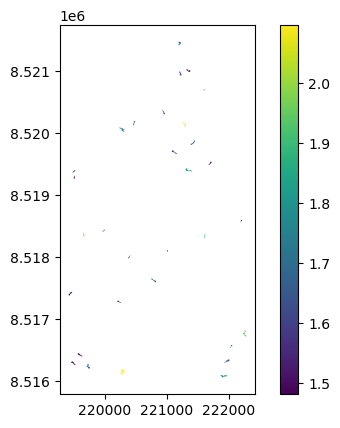

In [280]:
tile_filt = test_tile[(test_tile["compactness"] <= test_tile["compactness"].quantile(0.25)) & (test_tile["shape_index"] >= test_tile["shape_index"].quantile(0.75)) & (test_tile["interior_edge"] >= test_tile["interior_edge"].quantile(0.75)) & (test_tile["fractal_dim"] >= test_tile["fractal_dim"].quantile(0.75))]
tile_filt.info()

delta = .1 # buffer step
# max_len = max(tile_filt['perimeter_m'])
max_len = tile_filt.at[idx, 'perimeter_m']

for idx, row in tile_filt.iterrows(): 
    current_buff = 0
    while current_buff <= max_len: # update len per row?
        current_buff += delta
        buffered = row['geometry'].buffer(-current_buff)
        if buffered.geom_type == 'MultiPolygon':
            geoms = list(buffered.geoms) # extracting buffers
            print(f"Split happened for row {idx} at buffer distance {-current_buff}.")
            tile_filt.at[idx, 'buffers_geom'] = buffered # overall buffer geom
            tile_filt.at[idx, 'sdist'] = current_buff # buffer distance from perimeter
            tile_filt.at[idx, 'buffer_geom1'] = geoms[0] # geom 1 for split poly
            tile_filt.at[idx, 'buffer_geom2'] = geoms[1] # geom 2 for split poly
            break  
    else:
        print(f"No split for row {idx} within dimension limit")

tile_filt.dropna(subset = ['sdist']).plot(column="shape_index", cmap="viridis", legend=True)
plt.show()


In [ ]:
# Connecting narrowest part
for idx, row in test_tile.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
        test_tile.at[idx, 'pinch1'] = p1
        test_tile.at[idx, 'pinch2'] = p2
        test_tile.at[idx, 'line'] = LineString([p1, p2])

# Creating Cut Line (Perpendicular Line) and cutting
cut_geoms = []
for idx, row in test_tile.iterrows():
    if pd.isna(row['sdist']):
        continue
    else: 
        bounds = test_tile.at[idx, 'geometry'].bounds
        dist = max(bounds[2] - bounds[0], bounds[3] - bounds[1])
        point1 = test_tile.at[idx, 'pinch1']
        point2 = test_tile.at[idx, 'pinch2']
        dx = point1.x - point2.x
        dy = point1.y - point2.y
        midpoint = Point((point1.x + point2.x) / 2, (point1.y + point2.y) / 2)
        perp_slope = -(dx/dy)
        perp_line = LineString([(midpoint.x - dist, midpoint.y - perp_slope * dist), (midpoint.x + dist, midpoint.y + perp_slope * dist)])
        cut = split(test_tile.at[idx, 'geometry'], perp_line)
        test_tile.at[idx, 'cut_geom1'] = cut.geoms[0]
        test_tile.at[idx, 'cut_geom2'] = cut.geoms[1]

fig, ax = plt.subplots()
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom1'])['cut_geom1']).plot(ax=ax, facecolor='none', edgecolor='red')
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom2'])['cut_geom2']).plot(ax=ax, facecolor='none', edgecolor='blue')
plt.show()


In [ ]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom1'])['cut_geom1']).head(20).plot(ax=ax, facecolor='none', edgecolor='red')
gpd.GeoSeries(test_tile.dropna(subset=['cut_geom2'])['cut_geom2']).head(20).plot(ax=ax, facecolor='none', edgecolor='blue')
plt.show()

In [ ]:
display(zam_filt['geometry'].length)
zam_filt.info()

In [ ]:
# geopandas buffer function
zam_filt['geometry_test'] = zam_filt['geometry'].buffer(-2)

zam_filt

In [ ]:
zam_filt[]

In [ ]:
selected.geometry.bounds

In [ ]:
selected.geometry.bounds

selected['min_len'] = min((selected.geometry.bounds['maxx']-selected.geometry.bounds['minx']).values[0], (selected.geometry.bounds['maxy']-selected.geometry.bounds['miny']).values[0])/2

selected['min_len']

In [ ]:
selected['geometry'].bounds['minx']
selected.geometry.bounds['maxx']-selected.geometry.bounds['minx']

In [ ]:
# finding shorter dimension of every polygon and halving it (approximation for max buffer distance)
zam_filt['min_len'] = zam_filt.geometry.apply(
    lambda g: -(min(g.bounds[2] - g.bounds[0], g.bounds[3] - g.bounds[1]) / 2)
)

delta = -.5 # buffer step


for idx, row in zam_filt.iterrows():
    current_buff = 0
    while current_buff >= row['min_len']: 
        current_buff += delta
        buffered = row['geometry'].buffer(current_buff)
        if buffered.geom_type == 'MultiPolygon':
            geoms = list(buffered.geoms) # extracting buffers
            print(f"Split happened for row {idx} at buffer distance {current_buff}.")
            zam_filt.at[idx, 'geometry_test'] = buffered
            zam_filt.at[idx, 'sdist'] = current_buff
            zam_filt.at[idx, 'buffer_geom1'] = geoms[0]
            zam_filt.at[idx, 'buffer_geom2'] = geoms[1]
            break  
    else:
        print(f"No split for row {idx} within dimension limit")
 

In [ ]:
zam_filt

## open in arc and  check the width 

In [ ]:
   ## find where the two separate polygons are closest, this is where
    ## the internal buffering pinched off into two polygons.



from shapely.ops import nearest_points
from shapely.ops import split
from shapely import LineString

for idx, row in zam_filt.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
        zam_filt.at[idx, 'pinch1'] = p1
        zam_filt.at[idx, 'pinch2'] = p2
        zam_filt.at[idx, 'line'] = LineString([p1, p2])
        line_buff = row['line'].buffer(abs(row['sdist']))
        zam_filt.at[idx, 'line_buff'] = line_buff

        

In [ ]:

from shapely.ops import Point
from shapely.ops import snap

## use min_len * 10? maybe to incresae line ? 
## after identifying multi part polygon, reverse buffer ? 
## ideally it should perfectly touch at middle point and use as a mask to clip 
## distance buffer distance too? 

## work on multi neck problem later 

## Scaling function up ? corner cases (long, multiple necks, wide neck, etc etc)

for idx, row in zam_filt.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        dx = row['pinch2'].x - row['pinch1'].x
        dy = row['pinch2'].y - row['pinch1'].y
        length = sqrt(dx**2 + dy**2)
        dx, dy = dx/length * abs(row['sdist'])*20, dy/length * abs(row['sdist'])*20 # normalize to unit vector for x and y directions, multiple by sdist * 2 
        new_p1 = Point(row['pinch1'].x - dx, row['pinch1'].y - dy)
        new_p2 = Point(row['pinch2'].x + dx, row['pinch2'].y + dy)
        new_line = LineString([new_p1, new_p2])
        new_line = snap(new_line, row['geometry'], tolerance=1e-6)
        cut = split(row['geometry'], new_line)
        parts = list(cut.geoms)
        print(f"Row {idx}: {len(parts)} parts")
    
    if len(parts) < 2:
        gpd.GeoDataFrame(geometry=[row['geometry'], new_line]).plot(color=['blue','red'])
        continue
    
    zam_filt.at[idx, 'split_geom1'] = parts[0]
    zam_filt.at[idx, 'split_geom2'] = parts[1]
        parts = list(cut.geoms)
        zam_filt.at[idx, 'split_geom1'] = parts[0]
        zam_filt.at[idx, 'split_geom2'] = parts[1]


In [ ]:
zam_filt
    

In [ ]:
zam_filt

In [ ]:
zam_filt.iloc[[2]].plot(column="shape_index", cmap="viridis", legend=True)